In [27]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import xsdba

print(xsdba.__version__)

0.5.0


In [ ]:
# --- Create toy gridded data ---
time_train = pd.date_range("1980-01-01", "1989-12-31", freq="ME")  # 10 yrs training
time_test  = pd.date_range("1980-01-01", "1999-12-31", freq="ME")  # 20 yrs test
lat = np.linspace(-10, 10, 20)   # 4 grid cells
lon = np.linspace(100, 120, 40)  # 5 grid cells

rng = np.random.default_rng(42)

# Observed training precip
obs = xr.DataArray(
    rng.gamma(shape=2, scale=2, size=(len(time_train), len(lat), len(lon))),
    coords={"time": time_train, "lat": lat, "lon": lon},
    dims=("time","lat","lon",),
    name="pr",
    attrs={"units": "mm/month"}
)
obs

# Simulated training precip (biased low)
sim = xr.DataArray(
    rng.gamma(shape=1.5, scale=1.5, size=(len(time_train), len(lat), len(lon))),
    coords={"time": time_train, "lat": lat, "lon": lon},
    dims=("time","lat","lon",),
    name="pr",
    attrs={"units": "mm/month"}
)
sim

# Simulated test data
test = xr.DataArray(
    rng.gamma(shape=1.5, scale=1.5, size=(len(time_test), len(lat), len(lon))),
    coords={"time": time_test, "lat": lat, "lon": lon},
    dims=("time","lat","lon",),
    name="pr",
    attrs={"units": "mm/month"}
)

# set the test values for 1980-1989 the same as sim
test.loc[dict(time=slice("1980-01-01", "1989-12-31"))] = sim

# Grid dimensions
nlat = len(lat)
nlon = len(lon)
n_pixels = 50

# Generate 50 random (lat, lon) indices without replacement
rng = np.random.default_rng(42)
lat_idx = rng.choice(nlat, size=n_pixels, replace=True)  # can use replace=False if you want unique
lon_idx = rng.choice(nlon, size=n_pixels, replace=True)
na_pixels = list(zip(lat_idx, lon_idx))

# Set those pixels to NaN for all time steps
for i, j in na_pixels:
    test[:, i, j] = np.nan

# Check
print(test.isnull().sum(dim="time"))
test

<xarray.DataArray 'pr' (lat: 20, lon: 40)> Size: 6kB
array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0],
       [  0,   0,   0,   0,   0,   0, 240,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0, 240,   0,   0,   0,   0,
          0, 240, 240,   0, 240,   0,   0,   0,   0, 240,   0,   0,   0,
          0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 240,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 240, 240,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0],
       [  0,   

<xarray.DataArray 'pr' (time: 240, lat: 20, lon: 40)> Size: 2MB
array([[[ 3.17391945,  0.29128034,  5.85507981, ...,  1.00137336,
          1.92967049,  0.63806097],
        [ 4.05494843,  5.36872948,  2.18233179, ...,  0.96343562,
          1.45328614,  4.38680699],
        [ 2.05246997,  2.28919999,  2.15313936, ...,  0.5665955 ,
          2.00723274,  2.31390821],
        ...,
        [ 1.09071643,         nan,  1.43593166, ..., 10.0162819 ,
          2.82296578,  0.98613663],
        [ 3.25213995,  0.71397277,  1.88473358, ...,  0.32466493,
          1.97380476,  4.35331022],
        [ 1.8721588 ,  3.18029942,  0.59147325, ...,  0.16853061,
          0.52345929,  3.48625414]],

       [[ 6.14143687,  5.00218552,  6.38336294, ...,  7.21375066,
          0.38382316,  5.21661527],
        [ 0.84468734,  0.39699845,  2.19289724, ...,  3.11663139,
          0.10532207,  4.4329194 ],
        [ 2.61319742,  2.16859127,  1.95297045, ...,  0.14952451,
          1.81848601,  1.70491123],
...
        [ 2.03512171,         nan,  0.78403385, ...,  1.58403319,
          0.98505874,  2.35648884],
        [ 0.8227271 ,  2.20027103,  0.78631134, ...,  3.45496785,
          0.47733089,  1.87861316],
        [ 4.56630521,  9.19599266,  0.16850248, ...,  1.37299641,
          2.00831562,  2.03472161]],

       [[ 4.48795508,  3.8418892 ,  0.72242778, ...,  0.96638781,
          2.42821161,  1.6762667 ],
        [ 3.69558534,  1.9960041 ,  1.50192983, ...,  2.65500369,
          0.08814483,  0.13290742],
        [ 3.16888605,  3.5017083 ,  1.13312309, ...,  3.12882275,
          3.57476464,  1.10147791],
        ...,
        [ 2.02997101,         nan,  1.54566882, ...,  1.47163877,
          2.48152654,  3.28188662],
        [ 1.13147091,  2.77323976,  1.11189789, ...,  1.66242777,
          2.78053486,  1.35867284],
        [ 4.397066  ,  1.20133892,  2.40707872, ...,  3.75274966,
          4.96210894,  1.26980963]]], shape=(240, 20, 40))
Coordinates:
  * time     (time) datetime64[ns] 2kB 1980-01-31 1980-02-29 ... 1999-12-31
  * lat      (lat) float64 160B -10.0 -8.947 -7.895 -6.842 ... 7.895 8.947 10.0
  * lon      (lon) float64 320B 100.0 100.5 101.0 101.5 ... 119.0 119.5 120.0
Attributes:
    units:    mm/month

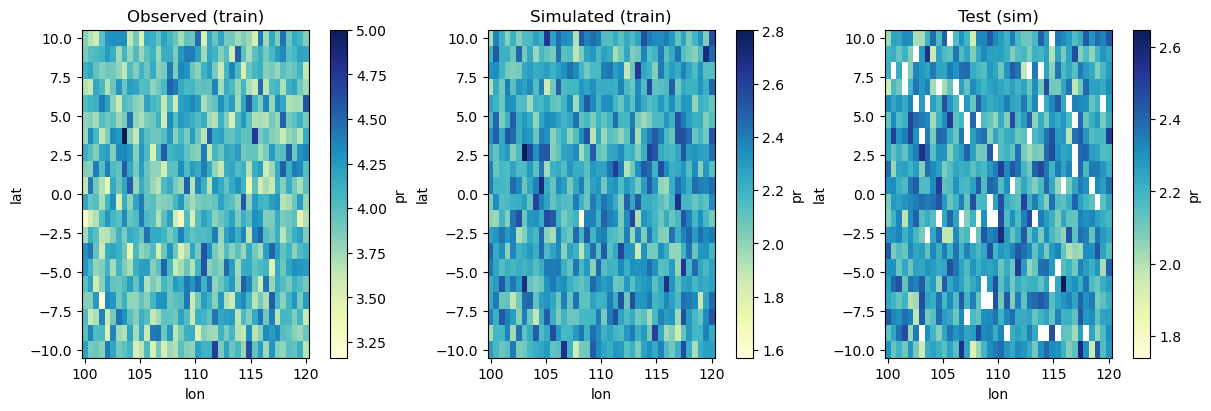

In [45]:
mean_obs = obs.groupby("time.year").mean("time", skipna=True).mean("year")
mean_sim = sim.groupby("time.year").mean("time", skipna=True).mean("year")
mean_test = test.groupby("time.year").mean("time", skipna=True).mean("year")

fig, axs = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
mean_obs.plot(ax=axs[0], cmap="YlGnBu"); axs[0].set_title("Observed (train)")
mean_sim.plot(ax=axs[1], cmap="YlGnBu"); axs[1].set_title("Simulated (train)")
mean_test.plot(ax=axs[2], cmap="YlGnBu"); axs[2].set_title("Test (sim)")

plt.show()

In [46]:
# --- Fit QDM ---
qdm = xsdba.adjustment.QuantileDeltaMapping.train(obs, sim, nquantiles=100, kind="*", group="time.month")

In [47]:
# --- Adjust test data with fitted QDM ---
adjTest = qdm.adjust(test, extrapolation="constant", interp="linear")

/home/dafcluster4/miniconda3/envs/xclim_stable/lib/python3.13/site-packages/xsdba/utils.py:399: RuntimeWarning: All-nan slice encountered in interp_on_quantiles
  warn(


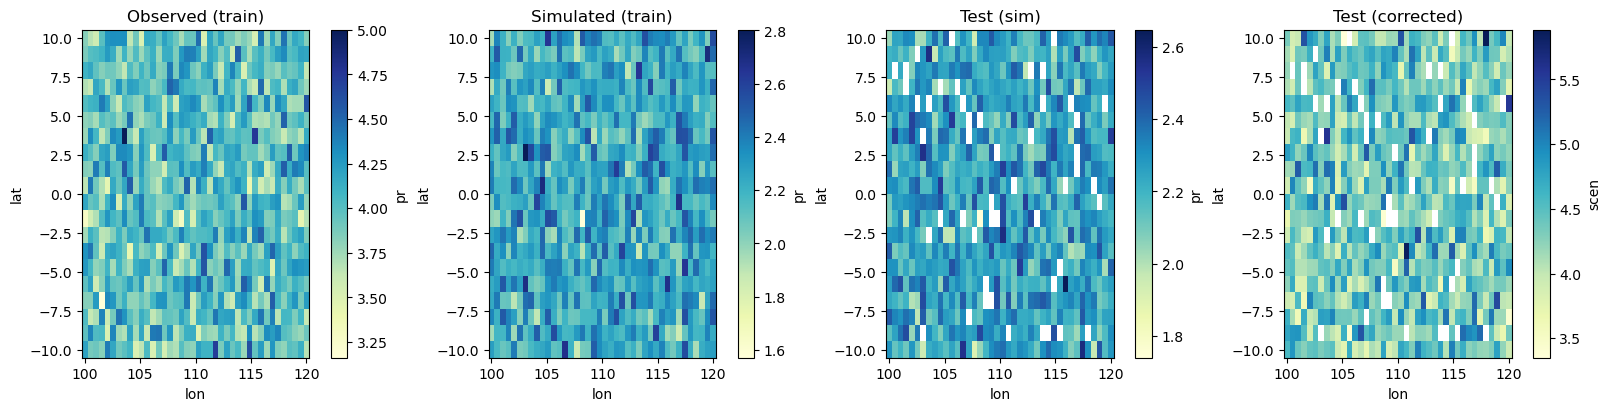

In [48]:
mean_corrected = adjTest.groupby("time.month").mean("time", skipna=True).mean("month")
fig, axs = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
mean_obs.plot(ax=axs[0], cmap="YlGnBu"); axs[0].set_title("Observed (train)")
mean_sim.plot(ax=axs[1], cmap="YlGnBu"); axs[1].set_title("Simulated (train)")
mean_test.plot(ax=axs[2], cmap="YlGnBu"); axs[2].set_title("Test (sim)")
mean_corrected.plot(ax=axs[3], cmap="YlGnBu"); axs[3].set_title("Test (corrected)")
plt.show()

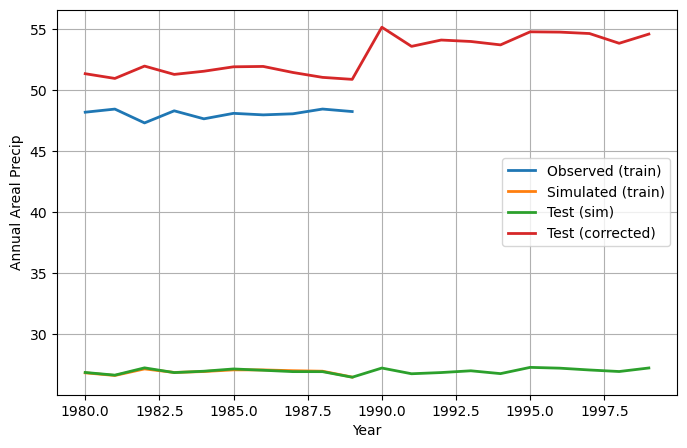

In [49]:
# --- Areal average time series ---
obs_area = obs.mean(["lat","lon"]).groupby("time.year").sum("time")
sim_area = sim.mean(["lat","lon"]).groupby("time.year").sum("time")
test_area = test.mean(["lat","lon"]).groupby("time.year").sum("time")
corrected_area = adjTest.mean(["lat","lon"]).groupby("time.year").sum("time")

fig2, ax2 = plt.subplots(figsize=(8,5))
ax2.plot(obs_area["year"], obs_area, label="Observed (train)", lw=2)
ax2.plot(sim_area["year"], sim_area, label="Simulated (train)", lw=2)
ax2.plot(test_area["year"], test_area, label="Test (sim)", lw=2)
ax2.plot(corrected_area["year"], corrected_area, label="Test (corrected)", lw=2)
ax2.set_ylabel("Annual Areal Precip")
ax2.set_xlabel("Year")
ax2.legend()
ax2.grid(True)
plt.show()

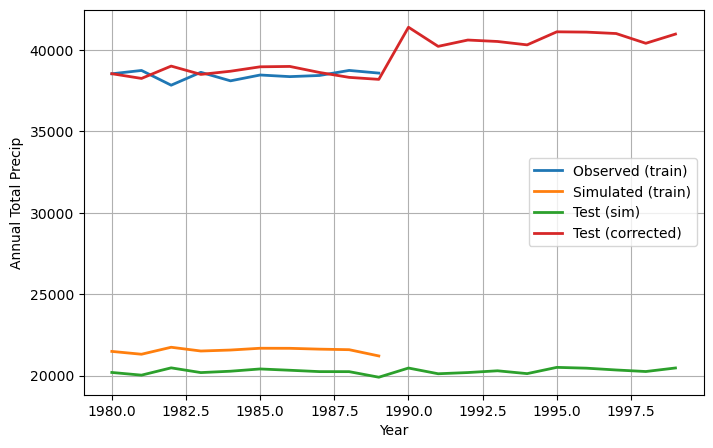

In [50]:
# --- Areal total time series ---
obs_area = obs.sum(["lat","lon"]).groupby("time.year").sum("time")
sim_area = sim.sum(["lat","lon"]).groupby("time.year").sum("time")
test_area = test.sum(["lat","lon"]).groupby("time.year").sum("time")
corrected_area = adjTest.sum(["lat","lon"]).groupby("time.year").sum("time")

fig3, ax3 = plt.subplots(figsize=(8,5))
ax3.plot(obs_area["year"], obs_area, label="Observed (train)", lw=2)
ax3.plot(sim_area["year"], sim_area, label="Simulated (train)", lw=2)
ax3.plot(test_area["year"], test_area, label="Test (sim)", lw=2)
ax3.plot(corrected_area["year"], corrected_area, label="Test (corrected)", lw=2)
ax3.set_ylabel("Annual Total Precip")
ax3.set_xlabel("Year")
ax3.legend()
ax3.grid(True)
plt.show()